In [2]:
from functools import partial

In [1]:
import pandas as pd

In [4]:
import numpy as np
from optuna import create_study, Trial
from scipy.optimize import rosen

In [5]:
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, make_scorer

In [6]:
%matplotlib inline

In [7]:
import matplotlib.pyplot as plt

## 1. Classic Optimization Problem - Rosenbrock Function

Rosenbrock function is given by [formula](https://en.wikipedia.org/wiki/Rosenbrock_function):


$$
f(x, y) = (1 - x)^2 + 100*(y- x^2)^2
$$

the problem is to find (the) minimum:

$$
(x_m, y_m) = 
\operatorname*{arg\,min}_{(x,y)\in\mathbb{R}^2}
f(x, y)
$$


In [10]:
x_grid = np.linspace(-2, 2, 201)
y_grid = np.linspace(-2, 2, 201)

In [12]:
x_coords, y_coords = np.meshgrid(x_grid, y_grid)

In [13]:
z_coords = rosen([x_coords, y_coords])

In [38]:
rosen_fig = plt.figure(figsize=(8, 6))

<Figure size 800x600 with 0 Axes>

In [39]:
rosen_axes = rosen_fig.add_subplot(1, 1, 1)

In [40]:
rosen_axes.contourf(x_coords, y_coords, z_coords, levels=100)

In [42]:
rosen_axes.scatter(1, 1, marker="x", s=100)

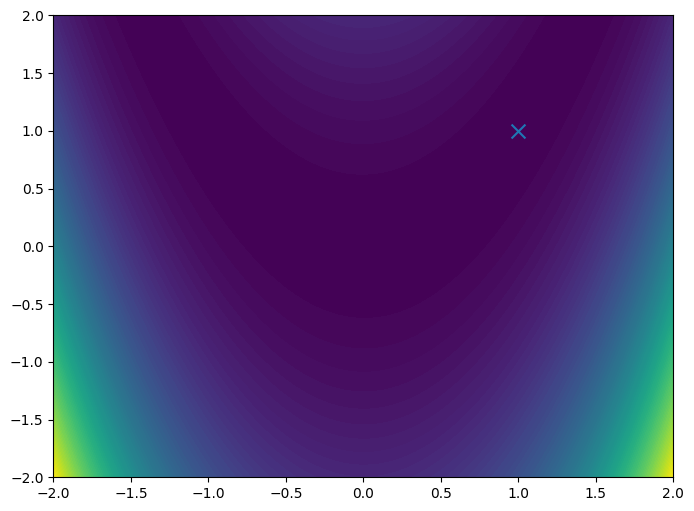

In [43]:
rosen_fig

## 2. Using *optuna* to Search for the Minimum of Rosenbrock

In [46]:
def objective(trial: Trial) -> float:
    x1 = trial.suggest_float("x1", -20, 20)
    x2 = trial.suggest_float("x2", -20, 20)
    return rosen([x1, x2])

In [49]:
def run_rosen_optimization() -> None:
    study = create_study(direction="minimize")
    study.optimize(func=objective, n_trials=1_000)
    return study.best_params

In [50]:
res = run_rosen_optimization()

[I 2026-05-12 22:18:18,551] A new study created in memory with name: no-name-3e97faf6-a339-4c3d-941d-2e498d375ee8
[I 2026-05-12 22:18:18,557] Trial 0 finished with value: 4659192.506050374 and parameters: {'x1': -14.782105510700942, 'x2': 2.664785569935093}. Best is trial 0 with value: 4659192.506050374.
[I 2026-05-12 22:18:18,558] Trial 1 finished with value: 4159707.6544902683 and parameters: {'x1': 14.171625706949932, 'x2': -3.1143852713828846}. Best is trial 1 with value: 4159707.6544902683.
[I 2026-05-12 22:18:18,559] Trial 2 finished with value: 4001.3654756328274 and parameters: {'x1': 1.5383121227045349, 'x2': -3.9590014884241675}. Best is trial 2 with value: 4001.3654756328274.
[I 2026-05-12 22:18:18,560] Trial 3 finished with value: 1169806.572691754 and parameters: {'x1': 10.199454852620775, 'x2': -4.124805007305388}. Best is trial 2 with value: 4001.3654756328274.
[I 2026-05-12 22:18:18,561] Trial 4 finished with value: 893.8427037075601 and parameters: {'x1': -2.9936682510

In [53]:
x1, x2 = res.values()

In [54]:
rosen_axes.scatter(x1, x2, marker="o", s=100)

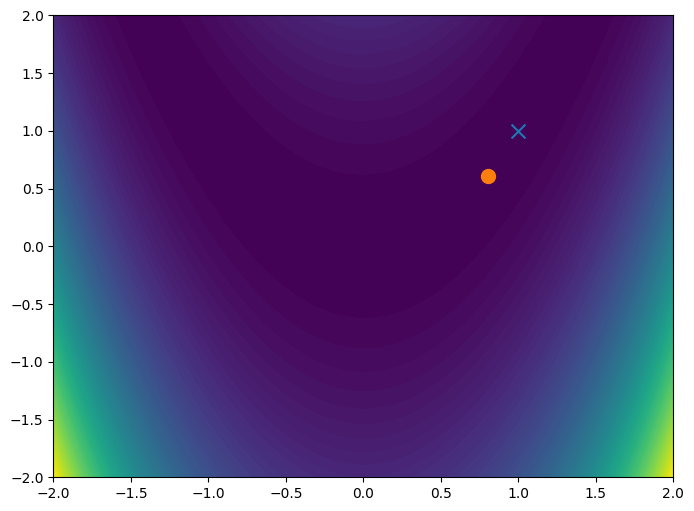

In [55]:
rosen_fig

## 3. Using *optuna* for Hyperparams Optimization